In [57]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from typing import List, Optional, Union, Tuple, Dict

In [58]:
# config -- 
LESS_SEVERE_RHO_VALUES_CSV = "less_severe_rho_values_mean.csv"
LESS_SEVERE_P_VALUES_CSV = "less_severe_p_values_mean.csv"
SEVERE_RHO_VALUES_CSV = "severe_rho_values_mean.csv"
SEVERE_P_VALUES_CSV = "severe_p_values_mean.csv"

PATH_COLS_TO_DROP = []
LESS_SEVERE_SAVE_FILE = "figures_v2/3/quabo_agg_less_severe_in_vitro_correlations.svg"
SEVERE_SAVE_FILE = "figures_v2/3/quabo_agg_severe_in_vitro_correlations.svg"


ALPHA = 0.05

In [59]:
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [60]:
from collections import OrderedDict
import re
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
import os

class CorrelationHeatmapPlotter:
    """
    Enhanced correlation plotting class that creates heatmap-style plots 
    for rho and p values with configurable rows and grouped X values.
    Shows non-significant correlations as light grey squares.
    """
    
    def __init__(self, 
                 less_severe_rho_file: str,
                 less_severe_p_file: str,
                 severe_rho_file: str,
                 severe_p_file: str,
                 alpha: float = 0.05):
        """
        Initialize with separate files for rho and p values for both severity levels.
        """
        self.less_severe_rho = self._load_and_align(less_severe_rho_file)
        self.less_severe_p = self._load_and_align(less_severe_p_file)
        self.severe_rho = self._load_and_align(severe_rho_file)
        self.severe_p = self._load_and_align(severe_p_file)
        self.alpha = alpha
        
        # Special value to mark non-significant correlations
        self.NONSIG_VALUE = 999.0
        
        # Get available pathology columns (excluding feature columns)
        self.pathology_columns = [col for col in self.less_severe_rho.columns 
                                 if col not in ['feature', 'feature_key']]
        
        # Define color scheme for different metrics
        self.metric_colors = {
            'AUC': '#2E8B57',      # SeaGreen
            'Einf': '#FF8C00',     # DarkOrange  
            'FxC': '#FF1493',      # DeepPink (for FIC/FBC)
            'GRmax': '#8A2BE2',    # BlueViolet
            'default': '#000000'   # Black for unrecognized metrics
        }
    
    def _save_figure(self, fig: plt.Figure, save_path: str, dpi: int = 300, 
                    bbox_inches: str = 'tight', debug: bool = False) -> None:
        """
        Save figure to specified path with proper directory creation.
        
        Parameters:
        -----------
        fig : plt.Figure
            The figure to save
        save_path : str
            Full path where to save the figure (including filename)
        dpi : int
            DPI for saving (default 300)
        bbox_inches : str
            Bbox setting for saving (default 'tight')
        debug : bool
            Whether to print debug information
        """
        if save_path is None:
            return
            
        # Extract directory from full path
        save_dir = os.path.dirname(save_path)
        
        # Create directory if it doesn't exist
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            if debug:
                print(f"Created/verified directory: {save_dir}")
        
        # Save the figure
        fig.savefig(save_path, dpi=dpi, bbox_inches=bbox_inches)
        if debug:
            print(f"Saved figure to: {save_path}")
    
    def _load_and_align(self, filepath: str) -> pd.DataFrame:
        """Load CSV and create aligned feature keys."""
        df = pd.read_csv(filepath)
        df = self._build_alignment(df)
        return df
    
    def _build_alignment(self, df: pd.DataFrame) -> pd.DataFrame:
        """Build feature alignment similar to correlations_plotting.ipynb."""
        df = df.copy()
        feat_col = next((c for c in df.columns if str(c).strip().lower() == "in_vitro_feature"), df.columns[0])
        df.rename(columns={feat_col: "feature"}, inplace=True)
        df["feature_key"] = df["feature"].map(self._canonical_feature)
        return df
    
    def _canonical_feature(self, s: str) -> Optional[str]:
        """Return canonical key for EQ/PK/LID features."""
        if s is None or (isinstance(s, float) and np.isnan(s)):
            return None
        s0 = str(s).strip()

        # LIDs (p-style; allow trailing spaces)
        m = re.match(r"^(?P<prefix>[57][NH])\s+(?P<pk>(?:casPK|cellPK|equip))\s+(?P<metric>AUC\d+|FBC\d+)\s*$",
                        s0, re.IGNORECASE)
        if m:
            return f"LID|{m.group('prefix').upper()}|{m.group('pk').lower()}|{m.group('metric').upper()}"

        # LIDs (rho-style variants)
        m = re.match(r"^(?P<prefix>[57][NH])\s*PK(?P<pk>cas|cell|equip)(?P<metric>AUC\d+|FBC\d+)\s*$",
                        s0, re.IGNORECASE)
        if m:
            return f"LID|{m.group('prefix').upper()}|{m.group('pk').lower()}|{m.group('metric').upper()}"

        # PK (rho-style) with OPTIONAL phase
        m = re.match(r"^PK(?P<which>cas|cell)(?P<subs>[A-Za-z]+)(?P<metric>AUC\d+|GRinf)(?P<phase>CT|C|T)?$",
                        s0, re.IGNORECASE)
        if m:
            which = m.group("which").lower()
            subs = m.group("subs").lower()
            metric = m.group("metric").upper()
            phase = (m.group("phase") or "").upper()
            return f"PK|{which}|{subs}|{metric}|{phase}"

        # PK (p-style)
        m = re.match(r"^PK_(?P<which>cas|cell)\s+(?P<metric>AUC\d+|GRinf)\s+(?P<subs>[A-Za-z]+)\s*\((?P<phase>[^)]+)\)\s*$",
                        s0, re.IGNORECASE)
        if m:
            return f"PK|{m.group('which').lower()}|{m.group('subs').lower()}|{m.group('metric').upper()}|{self._abbr_phase(m.group('phase'))}"

        # EQ (rho-style) with OPTIONAL phase
        m = re.match(r"^(?P<subs>[A-Za-z]+)(?P<metric>AUC\d+|FIC\d+|FBC\d+|GRinf)(?P<phase>CT|C|T)?$",
                        s0, re.IGNORECASE)
        if m:
            subs = m.group("subs").lower()
            metric = m.group("metric").upper()
            phase = (m.group("phase") or "").upper()
            return f"EQ|{metric}|{subs}|{phase}"

        # EQ (p-style)
        m = re.match(r"^(?P<metric>[A-Z]+[0-9]*|GRinf)\s+(?P<subs>[A-Za-z]+)\s*\((?P<phase>[^)]+)\)",
                        s0, re.IGNORECASE)
        if m:
            return f"EQ|{m.group('metric').upper()}|{m.group('subs').lower()}|{self._abbr_phase(m.group('phase'))}"

        return None
    
    def _abbr_phase(self, text: str) -> str:
        """Abbreviate phase descriptions."""
        t = str(text).strip().lower()
        if "constant" in t and "terminal" in t:
            return "CT"
        if "constant" in t:
            return "C"
        if "terminal" in t:
            return "T"
        return t[:1].upper() if t else ""
    
    def _extract_condition_from_feature(self, feature: str) -> str:
        """Extract condition name without timepoint suffix."""
        # Remove common timepoint suffixes
        patterns_to_remove = [
            r'_Constant$',
            r'_Terminal$', 
            r'_CT$',
            r'_C$',
            r'_T$',
            r'\s+\(constant\)$',
            r'\s+\(terminal\)$',
            r'Constant$',
            r'Terminal$'
        ]
        
        condition = feature
        for pattern in patterns_to_remove:
            condition = re.sub(pattern, '', condition, flags=re.IGNORECASE)
        
        return condition.strip()
    
    def _group_features_by_condition(self, features: List[str], rho_df: pd.DataFrame, 
                                   p_df: pd.DataFrame, pathology_cols: List[str], 
                                   debug: bool = False) -> Dict[str, str]:
        """
        Group features by condition and select the one with maximum absolute correlation.
        
        Returns:
        --------
        Dict[str, str]: Mapping from condition name to best feature name
        """
        condition_groups = {}
        condition_to_best = {}
        
        # Group features by condition
        for feature in features:
            condition = self._extract_condition_from_feature(feature)
            if condition not in condition_groups:
                condition_groups[condition] = []
            condition_groups[condition].append(feature)
        
        if debug:
            print(f"Found {len(condition_groups)} unique conditions from {len(features)} features")
        
        # For each condition group, find the feature with maximum absolute correlation
        for condition, condition_features in condition_groups.items():
            if len(condition_features) == 1:
                condition_to_best[condition] = condition_features[0]
                continue
            
            best_feature = None
            max_abs_corr = 0
            
            # Look across all pathology columns to find maximum absolute correlation
            for feature in condition_features:
                feature_max_abs_corr = 0
                
                for path_col in pathology_cols:
                    rho_val = self._get_value(rho_df, feature, path_col)
                    p_val = self._get_value(p_df, feature, path_col)
                    
                    if rho_val is not None and p_val is not None and p_val < self.alpha:
                        # Apply Einf flipping before taking absolute value
                        if 'einf' in feature.lower() or 'e_inf' in feature.lower():
                            rho_val = -rho_val
                        abs_corr = abs(rho_val)
                        if abs_corr > feature_max_abs_corr:
                            feature_max_abs_corr = abs_corr
                
                if feature_max_abs_corr > max_abs_corr:
                    max_abs_corr = feature_max_abs_corr
                    best_feature = feature
            
            # If no significant correlations found, take the first feature
            if best_feature is None:
                best_feature = condition_features[0]
            
            condition_to_best[condition] = best_feature
            
            if debug and len(condition_features) > 1:
                print(f"Condition '{condition}': {len(condition_features)} features -> selected '{best_feature}' (max_abs_corr={max_abs_corr:.3f})")
        
        return condition_to_best
    
    def _extract_metric_type(self, feature: str) -> str:
        """Extract metric type from feature name for color coding."""
        feature_upper = feature.upper()
        
        # Check for specific patterns - more comprehensive matching
        if 'AUC' in feature_upper:
            return 'AUC'
        elif 'EINF' in feature_upper or 'E_INF' in feature_upper:
            return 'Einf'
        elif any(pattern in feature_upper for pattern in ['FIC', 'FBC', 'F50', 'F90', 'FXC50', 'FXC90']):
            return 'FxC'
        elif 'GRMAX' in feature_upper or 'GR_MAX' in feature_upper or 'GR MAX' in feature_upper:
            return 'GRmax'
        else:
            return 'default'
    
    def _get_feature_colors(self, features: List[str]) -> List[str]:
        """Get color list for features based on their metric type."""
        colors = []
        for feature in features:
            metric_type = self._extract_metric_type(feature)
            colors.append(self.metric_colors[metric_type])
        return colors
    
    def _classify_feature_condition(self, condition: str) -> str:
        """Classify condition into simple equipotent, simple PK, or LIDS based on condition name."""
        condition_lower = condition.lower()
        
        # LIDS: conditions containing "5n", "7n", or "7h"
        if any(lid_marker in condition_lower for lid_marker in ["5n", "7n", "7h"]):
            return "LIDS"
        
        # Simple PK: conditions containing "cellpk" or "caspk" (but not LIDS markers)
        elif any(pk_marker in condition_lower for pk_marker in ["cellpk", "caspk"]):
            return "simple PK"
        
        # Simple equipotent: everything else
        else:
            return "simple equipotent"
    
    def _extract_condition_timepoint(self, feature: str) -> tuple:
        """Extract condition and timepoint from feature name for sorting."""
        feature_lower = feature.lower()
        
        # Try to extract timepoint (like C, T, CT at the end)
        timepoint = ""
        if feature_lower.endswith("ct"):
            timepoint = "CT"
        elif feature_lower.endswith("c"):
            timepoint = "C"
        elif feature_lower.endswith("t"):
            timepoint = "T"
        
        # Remove timepoint from condition for cleaner grouping
        condition = feature
        if timepoint:
            condition = feature[:-len(timepoint)].strip()
        
        return condition, timepoint
    
    def _categorize_feature(self, features: List[str]) -> Dict[str, List[str]]:
        """Categorize and sort features by condition-timepoint groupings."""
        
        # First, classify all features
        classified = {}
        for feature in features:
            classification = self._classify_feature_condition(feature)
            condition, timepoint = self._extract_condition_timepoint(feature)
            
            if classification not in classified:
                classified[classification] = {}
            if condition not in classified[classification]:
                classified[classification][condition] = []
            
            classified[classification][condition].append(feature)
        
        # Now organize in the requested order
        ordered_categories = OrderedDict()
        
        # Process in order: simple equipotent, simple PK, LIDS
        for classification in ["simple equipotent", "simple PK", "LIDS"]:
            if classification in classified:
                # Sort conditions alphabetically within each classification
                sorted_conditions = sorted(classified[classification].keys())
                
                for condition in sorted_conditions:
                    # Sort features within each condition (to handle multiple timepoints consistently)
                    sorted_features = sorted(classified[classification][condition])
                    
                    # Create a unique key for this condition group
                    group_key = f"{classification} - {condition}"
                    ordered_categories[group_key] = sorted_features
        
        return ordered_categories
    
    def _categorize_conditions(self, conditions: List[str]) -> List[str]:
        """Categorize and sort conditions using original logic: equipotent -> simple PK -> LIDS."""
        
        # Classify conditions
        equipotent_conditions = []
        simple_pk_conditions = []
        lids_conditions = []
        
        for condition in conditions:
            classification = self._classify_feature_condition(condition)
            if classification == "simple equipotent":
                equipotent_conditions.append(condition)
            elif classification == "simple PK":
                simple_pk_conditions.append(condition)
            else:  # LIDS
                lids_conditions.append(condition)
        
        # Sort within each category
        equipotent_conditions.sort()
        simple_pk_conditions.sort()
        lids_conditions.sort()
        
        # Combine in the desired order
        ordered_conditions = equipotent_conditions + simple_pk_conditions + lids_conditions
        
        return ordered_conditions
    
    def _categorize_conditions_by_type(self, conditions: List[str]) -> Dict[str, List[str]]:
        """Categorize conditions into separate groups by type."""
        
        # Classify conditions
        categories = {
            "simple equipotent": [],
            "simple PK": [], 
            "LIDS": []
        }
        
        for condition in conditions:
            classification = self._classify_feature_condition(condition)
            categories[classification].append(condition)
        
        # Sort within each category
        for category in categories:
            categories[category].sort()
        
        return categories
    
    def _pretty_metric(self, metric: str) -> str:
        """Format metric names for display."""
        m = metric.upper()
        if m.startswith("FIC") or m.startswith("FBC"):
            return "FxC" + re.sub(r"\D", "", m)
        if m.startswith("AUC"):
            return "AUC" + re.sub(r"\D", "", m)
        if m.startswith("GRINF"):
            return "GRinf"
        return m
    
    def _clean_feature_names(self, features: List[str]) -> List[str]:
        """Clean feature names for display."""
        cleaned = []
        for feature in features:
            clean_name = feature.replace("(constant)", "C").replace("(terminal)", "T")
            clean_name = re.sub(r'\s+', ' ', clean_name).strip()
            cleaned.append(clean_name)
        return cleaned
    
    def _apply_colored_xlabels(self, ax: plt.Axes, labels: List[str], colors: List[str]):
        """Apply colored labels to x-axis."""
        # Set the labels first
        ax.set_xticklabels(labels, rotation=90)
        
        # Get the tick labels and apply colors
        for tick_label, color in zip(ax.get_xticklabels(), colors):
            tick_label.set_color(color)
            tick_label.set_weight('bold')  # Make them bold for better visibility
    
    def _create_correlation_colormap_with_grey(self, cmap_colors=("#d73027", "#4575b4"), grey_color='#D3D3D3'):
        """
        Create a custom colormap that shows correlations in color and non-significant values as grey squares.
        
        Parameters:
        -----------
        cmap_colors : tuple
            Colors for negative and positive correlations
        grey_color : str  
            Color for non-significant correlations
        
        Returns:
        --------
        tuple : (colormap, normalizer)
            Custom colormap and normalizer for use with imshow/heatmap
        """
        
        # Create base correlation colormap (red to blue through white)
        colors = [
            cmap_colors[0],    # Strong red for negative correlations
            "#fee0d2",         # Light red 
            "#ffffff",         # White for zero
            "#deebf7",         # Light blue
            cmap_colors[1]     # Strong blue for positive correlations
        ]
        
        # Create discrete boundaries for better control
        n_corr_colors = 100
        base_cmap = LinearSegmentedColormap.from_list('correlation_base', colors, N=n_corr_colors)
        
        # Create boundaries: correlation values (-1 to 1) + special value for non-significant
        corr_bounds = np.linspace(-1, 1, n_corr_colors + 1)
        all_bounds = np.concatenate([corr_bounds, [self.NONSIG_VALUE - 0.1, self.NONSIG_VALUE + 0.1]])
        
        # Get colors: correlation colors + grey for non-significant
        corr_colors = [base_cmap(i / (n_corr_colors - 1)) for i in range(n_corr_colors)]
        all_colors = corr_colors + [mcolors.to_rgba(grey_color), mcolors.to_rgba(grey_color)]
        
        # Create the custom colormap and normalizer
        custom_cmap = ListedColormap(all_colors)
        custom_norm = BoundaryNorm(all_bounds, custom_cmap.N)
        
        return custom_cmap, custom_norm
    
    def _create_improved_colormap(self, cmap_colors: Tuple[str, str] = ("#d73027", "#4575b4")) -> LinearSegmentedColormap:
        """Create an improved colormap with better color differentiation (legacy method)."""
        # Use more distinct intermediate colors
        colors = [
            cmap_colors[0],    # Strong red for negative correlations
            "#fee0d2",         # Light red 
            "#ffffff",         # White for zero
            "#deebf7",         # Light blue
            cmap_colors[1]     # Strong blue for positive correlations
        ]
        n_bins = 256
        cmap = LinearSegmentedColormap.from_list('improved_correlation', colors, N=n_bins)
        return cmap
    
    def _get_data_statistics(self, data_matrix: np.ndarray, mask_matrix: np.ndarray) -> Dict[str, float]:
        """Get statistics about the correlation data for debugging."""
        valid_data = data_matrix[~mask_matrix]
        # Exclude non-significant marker values from statistics
        valid_data = valid_data[valid_data != self.NONSIG_VALUE]
        
        if len(valid_data) == 0:
            return {"min": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan, "n_values": 0}
        
        return {
            "min": np.min(valid_data),
            "max": np.max(valid_data),
            "mean": np.mean(valid_data),
            "std": np.std(valid_data),
            "n_values": len(valid_data),
            "n_positive": np.sum(valid_data > 0),
            "n_negative": np.sum(valid_data < 0),
            "n_zero": np.sum(valid_data == 0)
        }
    
    def print_data_summary(self, pathology_rows: Optional[List[str]] = None) -> None:
        """Print summary statistics about correlation data for debugging."""
        if pathology_rows is None:
            pathology_rows = self.pathology_columns
        
        all_features = self.less_severe_rho['feature'].tolist()
        
        print("=== DATA SUMMARY ===")
        print(f"Number of features: {len(all_features)}")
        print(f"Number of pathology measures: {len(pathology_rows)}")
        print(f"Alpha threshold: {self.alpha}")
        print(f"Non-significant marker value: {self.NONSIG_VALUE}")
        
        # Sample some features to check Einf detection
        einf_features = [f for f in all_features if 'einf' in f.lower() or 'e_inf' in f.lower()]
        print(f"\nDetected Einf features ({len(einf_features)}):")
        for feature in einf_features[:5]:  # Show first 5
            print(f"  - {feature}")
        if len(einf_features) > 5:
            print(f"  ... and {len(einf_features) - 5} more")
        
        # Check correlation value ranges
        for severity, rho_df, p_df in [
            ("Less Severe", self.less_severe_rho, self.less_severe_p),
            ("Severe", self.severe_rho, self.severe_p)
        ]:
            print(f"\n{severity} Lesions:")
            all_rho_vals = []
            all_p_vals = []
            significant_rho_vals = []
            
            for path_col in pathology_rows:
                for feature in all_features:
                    rho_val = self._get_value(rho_df, feature, path_col)
                    p_val = self._get_value(p_df, feature, path_col)
                    
                    if rho_val is not None:
                        all_rho_vals.append(rho_val)
                    if p_val is not None:
                        all_p_vals.append(p_val)
                    
                    if rho_val is not None and p_val is not None and p_val < self.alpha:
                        # Apply Einf flipping for summary
                        if 'einf' in feature.lower() or 'e_inf' in feature.lower():
                            rho_val = -rho_val
                        significant_rho_vals.append(rho_val)
            
            print(f"  All rho values: min={np.min(all_rho_vals):.3f}, max={np.max(all_rho_vals):.3f}, n={len(all_rho_vals)}")
            print(f"  Significant rho values (p<{self.alpha}): min={np.min(significant_rho_vals):.3f}, max={np.max(significant_rho_vals):.3f}, n={len(significant_rho_vals)}")
            print(f"  P-values: min={np.min(all_p_vals):.3f}, max={np.max(all_p_vals):.3f}")
    
    def create_legend(self, 
                     cmap_colors: Tuple[str, str] = ("#d73027", "#4575b4"),
                     figsize: Tuple[float, float] = (8, 1),
                     orientation: str = 'horizontal',
                     include_metric_legend: bool = True,
                     improved_colormap: bool = True,
                     show_grey_square: bool = True,
                     save_to: Optional[str] = None,
                     dpi: int = 300,
                     debug: bool = False) -> plt.Figure:
        """Create a separate legend figure for the correlation heatmaps with optional saving."""
        
        if improved_colormap:
            cmap = self._create_improved_colormap(cmap_colors)
        else:
            colors = [cmap_colors[0], 'grey', cmap_colors[1]]
            cmap = LinearSegmentedColormap.from_list('custom', colors, N=256)
        
        if include_metric_legend:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(figsize[0], figsize[1]*2))
        else:
            fig, ax1 = plt.subplots(figsize=figsize)
        
        # Create a dummy heatmap just for the colorbar
        dummy_data = np.linspace(-1, 1, 100).reshape(1, -1)
        
        im = ax1.imshow(dummy_data, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
        ax1.set_visible(False)  # Hide the dummy plot
        
        if orientation == 'horizontal':
            cbar = fig.colorbar(im, ax=ax1, orientation='horizontal', pad=0.1, shrink=0.8)
            cbar.set_label('Spearman ρ (Significant correlations)', fontsize=12)
            cbar.set_ticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])
        else:
            cbar = fig.colorbar(im, ax=ax1, orientation='vertical', pad=0.1, shrink=0.8)
            cbar.set_label('Spearman ρ (Significant correlations)', fontsize=12, rotation=270, labelpad=20)
            cbar.set_ticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])
        
        # Add metric color legend and grey square explanation
        if include_metric_legend:
            ax2.set_xlim(0, 1)
            ax2.set_ylim(0, 1)
            ax2.axis('off')
            
            # Create metric legend
            legend_elements = []
            for metric, color in self.metric_colors.items():
                if metric != 'default':  # Skip default color
                    legend_elements.append(
                        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=color, 
                                 markersize=10, label=metric, markeredgecolor='black')
                    )
            
            # Add grey square for non-significant correlations
            if show_grey_square:
                legend_elements.append(
                    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='#D3D3D3', 
                             markersize=10, label='p ≥ 0.05', markeredgecolor='black')
                )
            
            ax2.legend(handles=legend_elements, loc='center', ncol=len(legend_elements), 
                      title='Metric Types & Significance', title_fontsize=12, fontsize=10)
        
        plt.tight_layout()
        
        # Save if requested
        if save_to is not None:
            self._save_figure(fig, save_to, dpi=dpi, debug=debug)
        
        return fig
    
    def get_feature_sample(self, n_samples: int = 10) -> List[str]:
        """Get a sample of feature names to help with debugging metric detection."""
        all_features = self.less_severe_rho['feature'].tolist()
        return all_features[:n_samples] if len(all_features) > n_samples else all_features
    
    def debug_metric_detection(self, features: Optional[List[str]] = None) -> Dict[str, List[str]]:
        """Debug metric detection by showing which features are assigned to which colors."""
        if features is None:
            features = self.get_feature_sample()
        
        results = {}
        for metric_type in self.metric_colors.keys():
            results[metric_type] = []
        
        for feature in features:
            detected_type = self._extract_metric_type(feature)
            results[detected_type].append(feature)
        
        return results
    
    def _prepare_data_matrix(self, rho_df: pd.DataFrame, p_df: pd.DataFrame, 
                            pathology_rows: List[str], ordered_features: List[str], 
                            plot_type: str = 'rho', debug: bool = False):
        """Prepare data matrix for a single severity level with grey squares for non-significant values."""
        n_rows = len(pathology_rows)
        n_cols = len(ordered_features)
        
        if plot_type == 'rho':
            data_matrix = np.full((n_rows, n_cols), np.nan)
            mask_matrix = np.full((n_rows, n_cols), True, dtype=bool)
            
            einf_flipped_count = 0
            total_significant = 0
            total_nonsignificant = 0
            
            for i, path_col in enumerate(pathology_rows):
                for j, feature in enumerate(ordered_features):
                    # Get rho and p values
                    rho_val = self._get_value(rho_df, feature, path_col)
                    p_val = self._get_value(p_df, feature, path_col)
                    
                    if rho_val is not None and p_val is not None:
                        # Show rho if p < alpha (significant)
                        if p_val < self.alpha:
                            original_rho = rho_val
                            # Flip Einf correlations (multiply by -1)
                            if 'einf' in feature.lower() or 'e_inf' in feature.lower():
                                rho_val = -rho_val
                                einf_flipped_count += 1
                                if debug:
                                    print(f"Flipped Einf: {feature} from {original_rho:.3f} to {rho_val:.3f}")
                            data_matrix[i, j] = rho_val
                            mask_matrix[i, j] = False
                            total_significant += 1
                        else:
                            # Mark non-significant correlations with special value for grey squares
                            data_matrix[i, j] = self.NONSIG_VALUE
                            mask_matrix[i, j] = False
                            total_nonsignificant += 1
            
            if debug:
                print(f"Data preparation complete: {total_significant} significant correlations, {total_nonsignificant} non-significant, {einf_flipped_count} Einf values flipped")
                stats = self._get_data_statistics(data_matrix, mask_matrix)
                print(f"Final data range: {stats['min']:.3f} to {stats['max']:.3f}, mean: {stats['mean']:.3f}")
            
            return data_matrix, mask_matrix
            
        elif plot_type == 'p':
            data_matrix = np.full((n_rows, n_cols), np.nan)
            mask_matrix = np.full((n_rows, n_cols), True, dtype=bool)
            
            for i, path_col in enumerate(pathology_rows):
                for j, feature in enumerate(ordered_features):
                    p_val = self._get_value(p_df, feature, path_col)
                    
                    if p_val is not None:
                        data_matrix[i, j] = p_val
                        mask_matrix[i, j] = False
            
            return data_matrix, mask_matrix
    
    def create_individual_heatmap(self,
                                 severity: str = 'less_severe',  # 'less_severe' or 'severe'
                                 pathology_rows: Optional[List[str]] = None,
                                 include_features: Optional[List[str]] = None,
                                 exclude_features: Optional[List[str]] = None,
                                 plot_type: str = 'rho',  # 'rho' or 'p'
                                 figsize: Tuple[int, int] = (20, 6),
                                 cmap_colors: Tuple[str, str] = ("#d73027", "#4575b4"),
                                 title: Optional[str] = None,
                                 add_grid: bool = True,
                                 color_xlabels: bool = True,
                                 improved_colormap: bool = True,
                                 save_to: Optional[str] = None,
                                 dpi: int = 300,
                                 debug: bool = False,
                                 group_by_condition: bool = True) -> Tuple[plt.Figure, plt.Axes]:
        """
        Create a single heatmap for either less severe or severe lesions with grey squares for non-significant correlations.
        
        Parameters:
        -----------
        severity : str
            'less_severe' or 'severe'
        pathology_rows : List[str], optional
            Which pathology columns to include as rows
        include_features : List[str], optional
            Which features to include
        exclude_features : List[str], optional
            Which features to exclude
        plot_type : str
            'rho' for correlation values, 'p' for p-values
        figsize : Tuple[int, int]
            Figure size
        cmap_colors : Tuple[str, str]
            Colors for the colormap (negative, positive)
        title : str, optional
            Plot title (auto-generated if None)
        add_grid : bool
            Whether to add grid lines to the plot
        color_xlabels : bool
            Whether to color-code X-axis labels by metric type
        improved_colormap : bool
            Whether to use improved colormap with better differentiation
        save_to : str, optional
            Path to save the figure (including filename and extension)
        dpi : int
            DPI for saving (default 300)
        debug : bool
            Whether to print debug information
        group_by_condition : bool
            Whether to group features by condition and select max correlation (default True)
        """
        
        # Select data based on severity
        if severity == 'less_severe':
            rho_df = self.less_severe_rho
            p_df = self.less_severe_p
            severity_label = "Less Severe Lesions"
        else:
            rho_df = self.severe_rho
            p_df = self.severe_p
            severity_label = "Severe Lesions"
        
        # Filter pathology columns
        if pathology_rows is None:
            pathology_rows = self.pathology_columns
        else:
            pathology_rows = [col for col in pathology_rows if col in self.pathology_columns]
        
        # Get features
        all_features = rho_df['feature'].tolist()
        
        # Filter features
        if include_features is not None:
            features = [f for f in include_features if f in all_features]
        else:
            features = all_features.copy()
        
        if exclude_features is not None:
            features = [f for f in features if f not in exclude_features]
        
        # Group features by condition and select best representatives
        if group_by_condition:
            condition_to_best = self._group_features_by_condition(
                features, rho_df, p_df, pathology_rows, debug=debug
            )
            
            # Get ordered conditions using original sorting logic
            all_conditions = list(condition_to_best.keys())
            ordered_conditions = self._categorize_conditions(all_conditions)
            ordered_features = [condition_to_best[condition] for condition in ordered_conditions]
            display_features = ordered_conditions  # Use condition names for display
            
            if debug:
                print(f"Reduced {len(features)} features to {len(ordered_features)} conditions")
                print(f"Condition order: {ordered_conditions}")
        else:
            # Use original logic without grouping
            feature_categories = self._categorize_feature(features)
            ordered_features, category_boundaries, pos = [], [], 0
            for category_key, cat_features in feature_categories.items():
                ordered_features.extend(cat_features)
                main_class = category_key.split(' - ')[0]
                category_boundaries.append((pos, pos + len(cat_features), main_class))
                pos += len(cat_features)
            
            display_features = self._clean_feature_names(ordered_features)
        
        # Prepare data matrix
        data_matrix, mask_matrix = self._prepare_data_matrix(
            rho_df, p_df, pathology_rows, ordered_features, plot_type, debug=debug
        )
        
        # Set up figure
        fig, ax = plt.subplots(figsize=figsize)
        
        # Set up colormap and create heatmap
        if plot_type == 'p':
            # Standard p-value plot
            sns.heatmap(data_matrix, mask=mask_matrix,
                       xticklabels=display_features, yticklabels=pathology_rows,
                       cmap='viridis_r', vmin=0, vmax=1,
                       ax=ax, cbar=True, square=False,
                       cbar_kws={'shrink': 0.8, 'aspect': 20})
        else:
            # Correlation plot with grey squares for non-significant values
            custom_cmap, custom_norm = self._create_correlation_colormap_with_grey(cmap_colors)
            
            # Use imshow for better control over the colormap
            im = ax.imshow(data_matrix, cmap=custom_cmap, norm=custom_norm, aspect='auto')
            
            # Set up ticks and labels
            ax.set_xticks(range(len(display_features)))
            ax.set_yticks(range(len(pathology_rows)))
            ax.set_xticklabels(display_features, rotation=90)
            ax.set_yticklabels(pathology_rows)
            
            # Add colorbar manually
            cbar = plt.colorbar(im, ax=ax, shrink=0.8)
            cbar.set_label('Spearman ρ (Grey = p ≥ 0.05)', rotation=270, labelpad=15)
            
            # Set colorbar ticks to only show correlation range
            cbar.set_ticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])
        
        # Add colored X-axis labels if requested
        if color_xlabels:
            label_colors = self._get_feature_colors(ordered_features)
            self._apply_colored_xlabels(ax, display_features, label_colors)
        
        # Add grid lines if requested
        if add_grid:
            ax.grid(True, linestyle='-', alpha=0.3, color='white', linewidth=0.5)
            ax.set_axisbelow(True)
        
        # Set title
        if title is None:
            title = f"{severity_label} - {plot_type.upper()}"
            if group_by_condition:
                title += " (Max correlation per condition)"
        ax.set_title(title, fontsize=14, pad=25)
        
        # Set axis labels
        ax.set_xlabel("In vitro feature" + (" (condition)" if group_by_condition else ""), fontsize=12)
        ax.set_ylabel("Pathology measure", fontsize=12)
        
        plt.tight_layout()
        
        # Save if requested
        if save_to is not None:
            self._save_figure(fig, save_to, dpi=dpi, debug=debug)
        
        return fig, ax
    
    def create_category_heatmaps(self,
                                severity: str = 'less_severe',  # 'less_severe' or 'severe'
                                pathology_rows: Optional[List[str]] = None,
                                include_features: Optional[List[str]] = None,
                                exclude_features: Optional[List[str]] = None,
                                plot_type: str = 'rho',  # 'rho' or 'p'
                                figsize: Tuple[int, int] = (20, 6),
                                cmap_colors: Tuple[str, str] = ("#d73027", "#4575b4"),
                                add_grid: bool = True,
                                color_xlabels: bool = True,
                                improved_colormap: bool = True,
                                save_dir: str = "figures_v2/3/",
                                dpi: int = 300,
                                debug: bool = False,
                                group_by_condition: bool = True) -> Dict[str, Tuple[plt.Figure, plt.Axes]]:
        """
        Create separate heatmap files for each feature category (simple, PK, LIDS) with fixed square sizes.
        
        Returns:
        --------
        Dict mapping category names to (figure, axes) tuples
        """
        
        # Select data based on severity
        if severity == 'less_severe':
            rho_df = self.less_severe_rho
            p_df = self.less_severe_p
            severity_label = "Less Severe Lesions"
            severity_short = "less_severe"
        else:
            rho_df = self.severe_rho
            p_df = self.severe_p
            severity_label = "Severe Lesions"
            severity_short = "severe"
        
        # Filter pathology columns
        if pathology_rows is None:
            pathology_rows = self.pathology_columns
        else:
            pathology_rows = [col for col in pathology_rows if col in self.pathology_columns]
        
        # Get features
        all_features = rho_df['feature'].tolist()
        
        # Filter features
        if include_features is not None:
            features = [f for f in include_features if f in all_features]
        else:
            features = all_features.copy()
        
        if exclude_features is not None:
            features = [f for f in features if f not in exclude_features]
        
        # Group features by condition and categorize
        if group_by_condition:
            condition_to_best = self._group_features_by_condition(
                features, rho_df, p_df, pathology_rows, debug=debug
            )
            
            # Get conditions categorized by type
            all_conditions = list(condition_to_best.keys())
            categorized_conditions = self._categorize_conditions_by_type(all_conditions)
            
            if debug:
                print(f"Reduced {len(features)} features to {len(all_conditions)} conditions")
                for category, conditions in categorized_conditions.items():
                    print(f"{category}: {len(conditions)} conditions")
            
        else:
            raise ValueError("create_category_heatmaps requires group_by_condition=True")
        
        # Create separate plots for each category
        figures = {}
        category_name_mapping = {
            "simple equipotent": "simple",
            "simple PK": "pk", 
            "LIDS": "lids"
        }
        
        for category_full_name, conditions in categorized_conditions.items():
            if not conditions:  # Skip empty categories
                continue
                
            category_short = category_name_mapping[category_full_name]
            
            # Get features and display names for this category
            ordered_features = [condition_to_best[condition] for condition in conditions]
            display_features = conditions
            
            # Prepare data matrix for this category
            data_matrix, mask_matrix = self._prepare_data_matrix(
                rho_df, p_df, pathology_rows, ordered_features, plot_type, debug=debug
            )
            
            # Use fixed square size across all plots
            square_size_inches = 0.6  # Fixed size per grid square in inches
            n_conditions = len(ordered_features)
            n_pathology = len(pathology_rows)

            # Calculate figure size based on fixed square dimensions
            plot_width = n_conditions * square_size_inches
            plot_height = n_pathology * square_size_inches

            # Add margins for labels and colorbar
            margin_left = 2.0  # Space for y-axis labels
            margin_bottom = 2.5  # Space for x-axis labels (rotated)
            margin_right = 1.5   # Space for colorbar
            margin_top = 1.0     # Space for title

            total_width = plot_width + margin_left + margin_right
            total_height = plot_height + margin_bottom + margin_top

            adjusted_figsize = (total_width, total_height)

            # Set up figure with fixed square sizing
            fig, ax = plt.subplots(figsize=adjusted_figsize)

            # Position the axes to maintain fixed square aspect ratios
            ax_left = margin_left / total_width
            ax_bottom = margin_bottom / total_height
            ax_width = plot_width / total_width
            ax_height = plot_height / total_height

            ax.set_position([ax_left, ax_bottom, ax_width, ax_height])
            
            # Set up colormap and create heatmap
            if plot_type == 'p':
                # Standard p-value plot
                sns.heatmap(data_matrix, mask=mask_matrix,
                           xticklabels=display_features, yticklabels=pathology_rows,
                           cmap='viridis_r', vmin=0, vmax=1,
                           ax=ax, cbar=True, square=True,
                           cbar_kws={'shrink': 0.8, 'aspect': 20})
            else:
                # Correlation plot with grey squares for non-significant values
                custom_cmap, custom_norm = self._create_correlation_colormap_with_grey(cmap_colors)
                
                # Use imshow for better control over the colormap and force square aspect
                im = ax.imshow(data_matrix, cmap=custom_cmap, norm=custom_norm, aspect='equal')
                
                # Set up ticks and labels
                ax.set_xticks(range(len(display_features)))
                ax.set_yticks(range(len(pathology_rows)))
                ax.set_xticklabels(display_features, rotation=90)
                ax.set_yticklabels(pathology_rows)
                
                # Create colorbar with manual positioning to maintain square aspect
                divider = plt.matplotlib.axes.Axes.get_position(ax)
                cbar_ax = fig.add_axes([divider.x1 + 0.02, divider.y0, 0.02, divider.height])
                cbar = fig.colorbar(im, cax=cbar_ax)
                cbar.set_label('Spearman ρ (Grey = p ≥ 0.05)', rotation=270, labelpad=15)
                
                # Set colorbar ticks to only show correlation range
                cbar.set_ticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])
            
            # Add colored X-axis labels if requested
            if color_xlabels:
                label_colors = self._get_feature_colors(ordered_features)
                self._apply_colored_xlabels(ax, display_features, label_colors)
            
            # Add grid lines if requested
            if add_grid:
                ax.grid(True, linestyle='-', alpha=0.3, color='white', linewidth=0.5)
                ax.set_axisbelow(True)
            
            # Set title
            title = f"{severity_label} - {category_full_name.title()}"
            if group_by_condition:
                title += " (Max correlation per condition)"
            ax.set_title(title, fontsize=14, pad=25)
            
            # Set axis labels
            ax.set_xlabel("In vitro feature (condition)", fontsize=12)
            ax.set_ylabel("Pathology measure", fontsize=12)
            
            # Save the figure without tight_layout to preserve fixed positioning
            filename = f"{severity_short}_{category_short}.svg"
            save_path = os.path.join(save_dir, filename)
            self._save_figure(fig, save_path, dpi=dpi, bbox_inches=None, debug=debug)  # Don't use tight bbox
            
            # Store the figure
            figures[category_short] = (fig, ax)
            
            if debug:
                print(f"Created {category_full_name} plot with {len(conditions)} conditions: {filename}")
                print(f"  Figure size: {adjusted_figsize}, Plot area: {plot_width:.2f} x {plot_height:.2f} inches")
                print(f"  Square size: {square_size_inches} inches per grid cell")
        
        return figures
    
    def _get_value(self, df: pd.DataFrame, feature: str, column: str):
        """Get a single value from dataframe for given feature and column."""
        if column not in df.columns:
            return None
        
        row = df[df['feature'] == feature]
        if row.empty:
            return None
        
        val = row[column].iloc[0]
        return val if pd.notna(val) else None

In [61]:
def load_correlation_plotter(less_severe_rho_file: str = "less_severe_rho_values_mean.csv",
                           less_severe_p_file: str = "less_severe_p_values_mean.csv", 
                           severe_rho_file: str = "severe_rho_values_mean.csv",
                           severe_p_file: str = "severe_p_values_mean.csv",
                           alpha: float = 0.05) -> CorrelationHeatmapPlotter:
    """Convenience function to load correlation plotter with default files."""
    return CorrelationHeatmapPlotter(
        less_severe_rho_file, less_severe_p_file,
        severe_rho_file, severe_p_file, alpha
    )

=== DEBUGGING INFORMATION ===
=== DATA SUMMARY ===
Number of features: 126
Number of pathology measures: 4
Alpha threshold: 0.05
Non-significant marker value: 999.0

Detected Einf features (27):
  - Einf_butyrate_Constant
  - Einf_butyrate_Terminal
  - Einf_cholesterol_Constant
  - Einf_cholesterol_Terminal
  - Einf_dormancy_Constant
  ... and 22 more

Less Severe Lesions:
  All rho values: min=-0.933, max=1.000, n=504
  Significant rho values (p<0.05): min=-0.886, max=1.000, n=27
  P-values: min=0.000, max=1.000

Severe Lesions:
  All rho values: min=-0.867, max=0.943, n=504
  Significant rho values (p<0.05): min=-0.867, max=0.943, n=55
  P-values: min=0.001, max=1.000




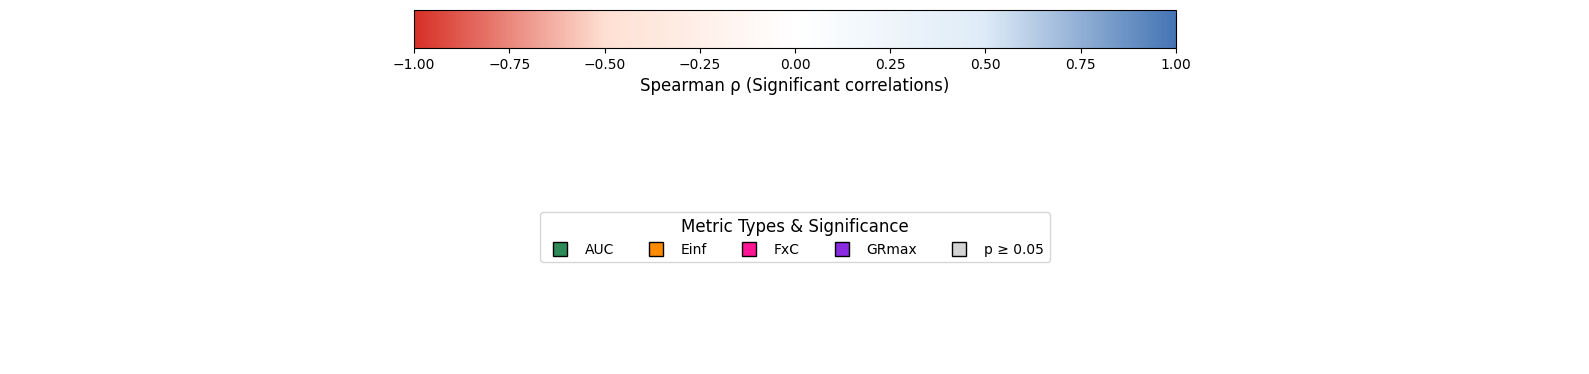

In [62]:
pathology_rows = ["delta_TotalVol",
                  "TP6_TotalVol",
                  "delta_MeanHU",
                  "TP6_MeanHU"]

# ^ invert for rotation

# Example in vitro features to include (X-axis filtering)
# These should be actual in vitro feature names from your data
include_in_vitro_features = None  # Set to None to include all, or provide list like:
# include_in_vitro_features = ["AUC50 cholesterol (constant)", "FIC90 butyrate (terminal)", ...]

plotter = load_correlation_plotter(alpha=ALPHA)

# Print data summary for debugging
print("=== DEBUGGING INFORMATION ===")
plotter.print_data_summary(pathology_rows)
print("\n" + "="*50 + "\n")

# Create enhanced legend that includes information about grey squares
legend_fig = plotter.create_legend(figsize=(16,3), orientation='horizontal', include_metric_legend=True, 
                                  improved_colormap=True, show_grey_square=True, save_to="figures_v2/3/quabo_correlations_legend.svg")

Creating individual heatmaps with improved colormap and debug info...

=== LESS SEVERE LESIONS - CATEGORY BREAKDOWN ===
Found 81 unique conditions from 126 features
Condition 'Einf_butyrate': 2 features -> selected 'Einf_butyrate_Constant' (max_abs_corr=0.000)
Condition 'Einf_cholesterol': 2 features -> selected 'Einf_cholesterol_Constant' (max_abs_corr=0.000)
Condition 'Einf_dormancy': 2 features -> selected 'Einf_dormancy_Constant' (max_abs_corr=0.000)
Condition 'Einf_butyrateCellPK': 2 features -> selected 'Einf_butyrateCellPK_Constant' (max_abs_corr=0.000)
Condition 'Einf_cholesterolCellPK': 2 features -> selected 'Einf_cholesterolCellPK_Constant' (max_abs_corr=0.819)
Condition 'Einf_dormancyCellPK': 2 features -> selected 'Einf_dormancyCellPK_Terminal' (max_abs_corr=0.933)
Condition 'Einf_butyrateCasPK': 2 features -> selected 'Einf_butyrateCasPK_Constant' (max_abs_corr=0.000)
Condition 'Einf_cholesterolCasPK': 2 features -> selected 'Einf_cholesterolCasPK_Constant' (max_abs_corr=

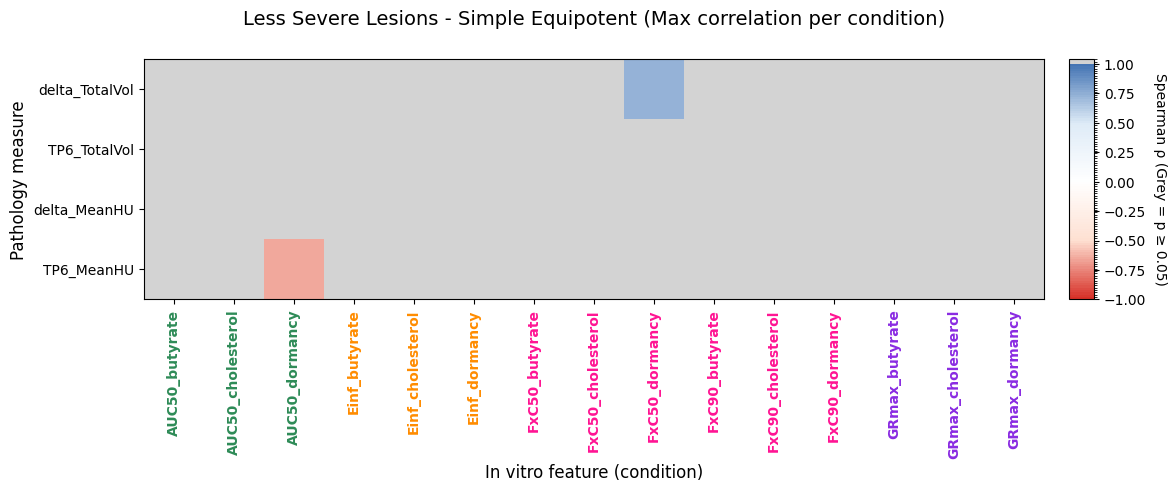

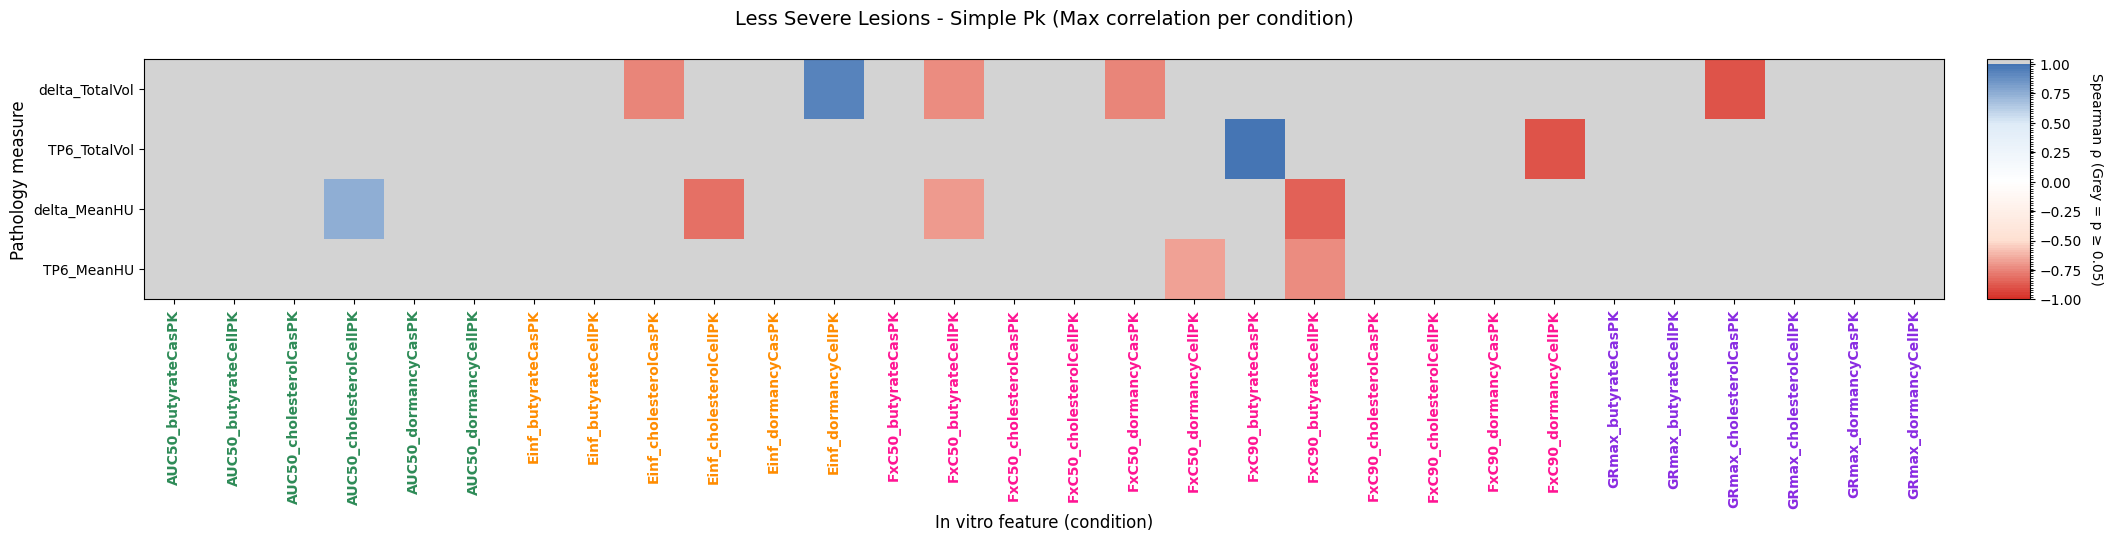

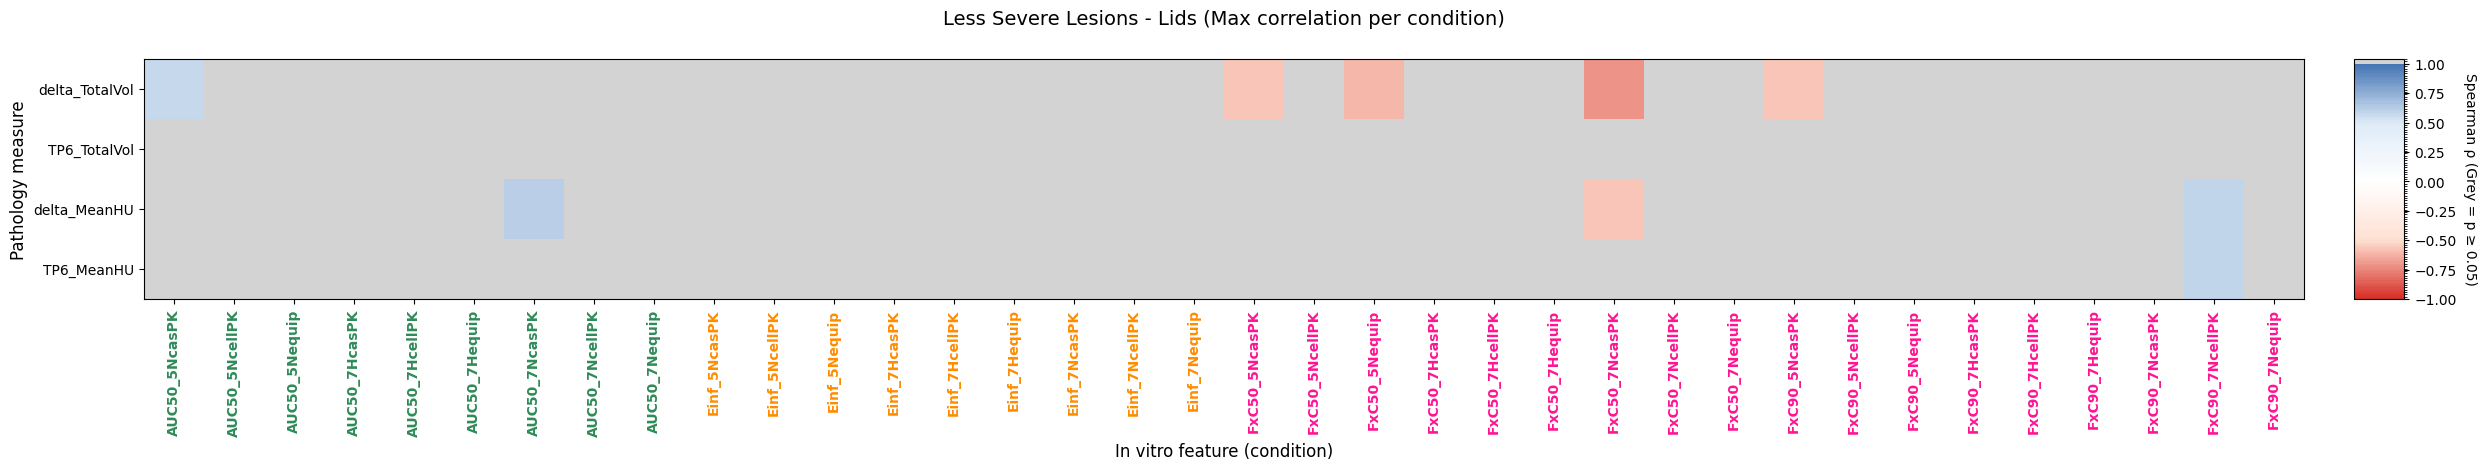


Showing pk category plot:

Showing lids category plot:

Created 3 separate files for less severe lesions:


In [63]:
# Create individual heatmaps for each severity level with improved colormap and debugging
print("Creating individual heatmaps with improved colormap and debug info...")

# Less severe lesions - create separate category files
print("\n=== LESS SEVERE LESIONS - CATEGORY BREAKDOWN ===")
less_severe_figures = plotter.create_category_heatmaps(
    severity='less_severe',
    plot_type='rho',
    add_grid=False,
    color_xlabels=True,  # Enable color-coded X-axis labels
    improved_colormap=True,  # Use improved colormap
    debug=True,  # Enable debug output
    pathology_rows=pathology_rows,  # Y-axis: which pathology measures to show
    save_dir="figures_v2/3/",
    include_features=include_in_vitro_features,  # X-axis: which in vitro features to show
    group_by_condition=True  # Group features by condition and select max correlation
)

# Display the figures
for category, (fig, ax) in less_severe_figures.items():
    print(f"\nShowing {category} category plot:")
    plt.show()

print(f"\nCreated {len(less_severe_figures)} separate files for less severe lesions:")


=== SEVERE LESIONS - CATEGORY BREAKDOWN ===
Found 81 unique conditions from 126 features
Condition 'Einf_butyrate': 2 features -> selected 'Einf_butyrate_Constant' (max_abs_corr=0.000)
Condition 'Einf_cholesterol': 2 features -> selected 'Einf_cholesterol_Constant' (max_abs_corr=0.000)
Condition 'Einf_dormancy': 2 features -> selected 'Einf_dormancy_Constant' (max_abs_corr=0.000)
Condition 'Einf_butyrateCellPK': 2 features -> selected 'Einf_butyrateCellPK_Terminal' (max_abs_corr=0.817)
Condition 'Einf_cholesterolCellPK': 2 features -> selected 'Einf_cholesterolCellPK_Constant' (max_abs_corr=0.000)
Condition 'Einf_dormancyCellPK': 2 features -> selected 'Einf_dormancyCellPK_Constant' (max_abs_corr=0.767)
Condition 'Einf_butyrateCasPK': 2 features -> selected 'Einf_butyrateCasPK_Terminal' (max_abs_corr=0.717)
Condition 'Einf_cholesterolCasPK': 2 features -> selected 'Einf_cholesterolCasPK_Constant' (max_abs_corr=0.708)
Condition 'Einf_dormancyCasPK': 2 features -> selected 'Einf_dormanc

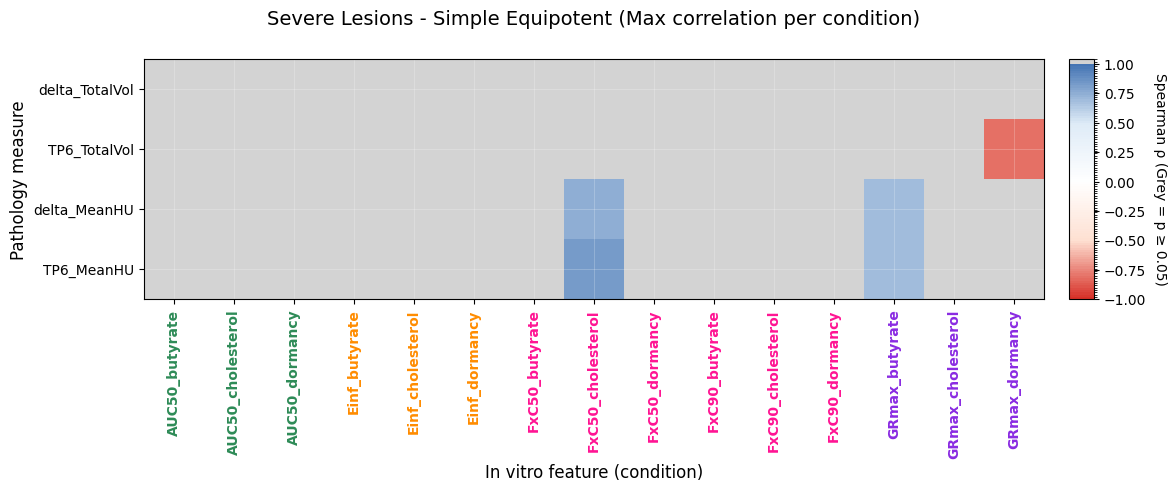

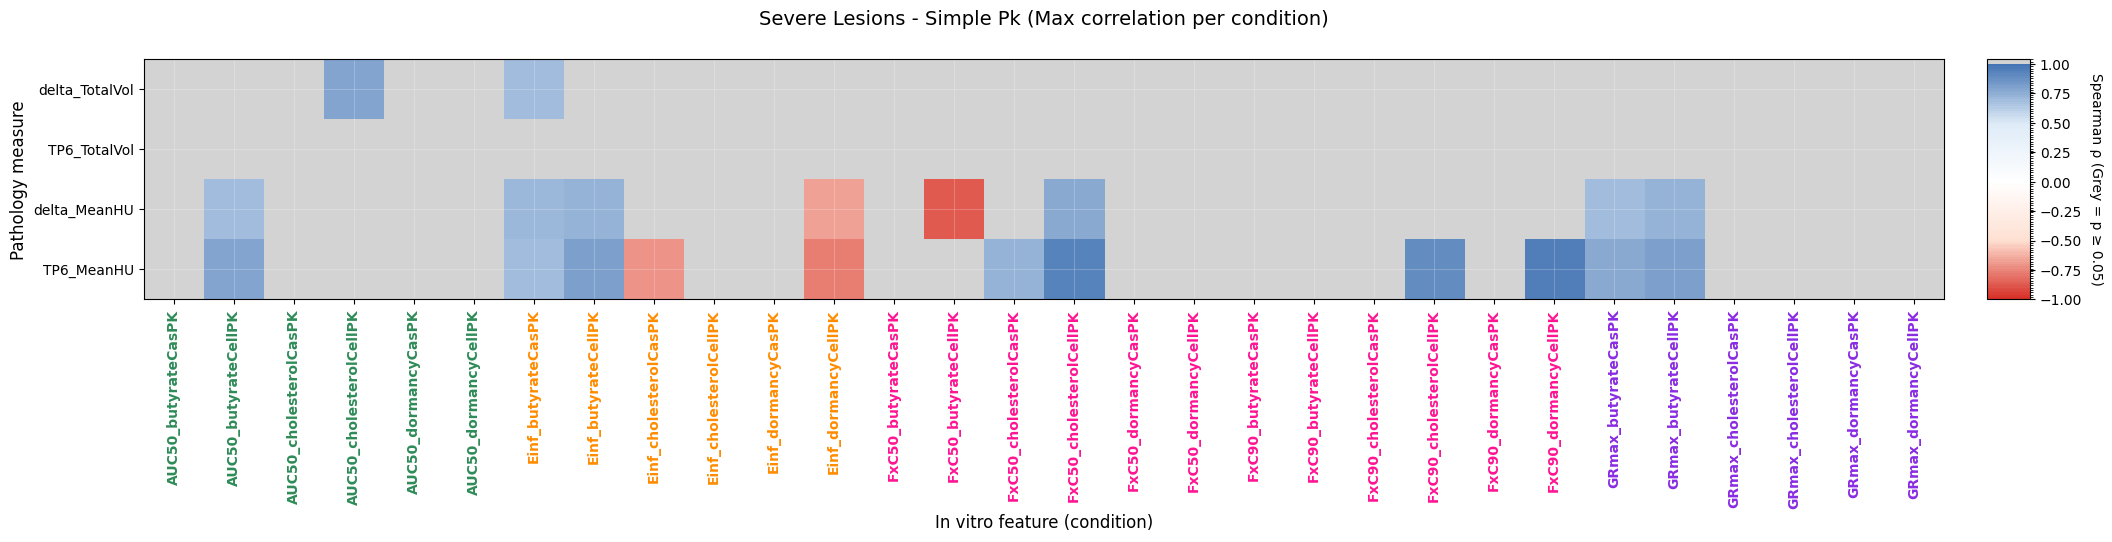

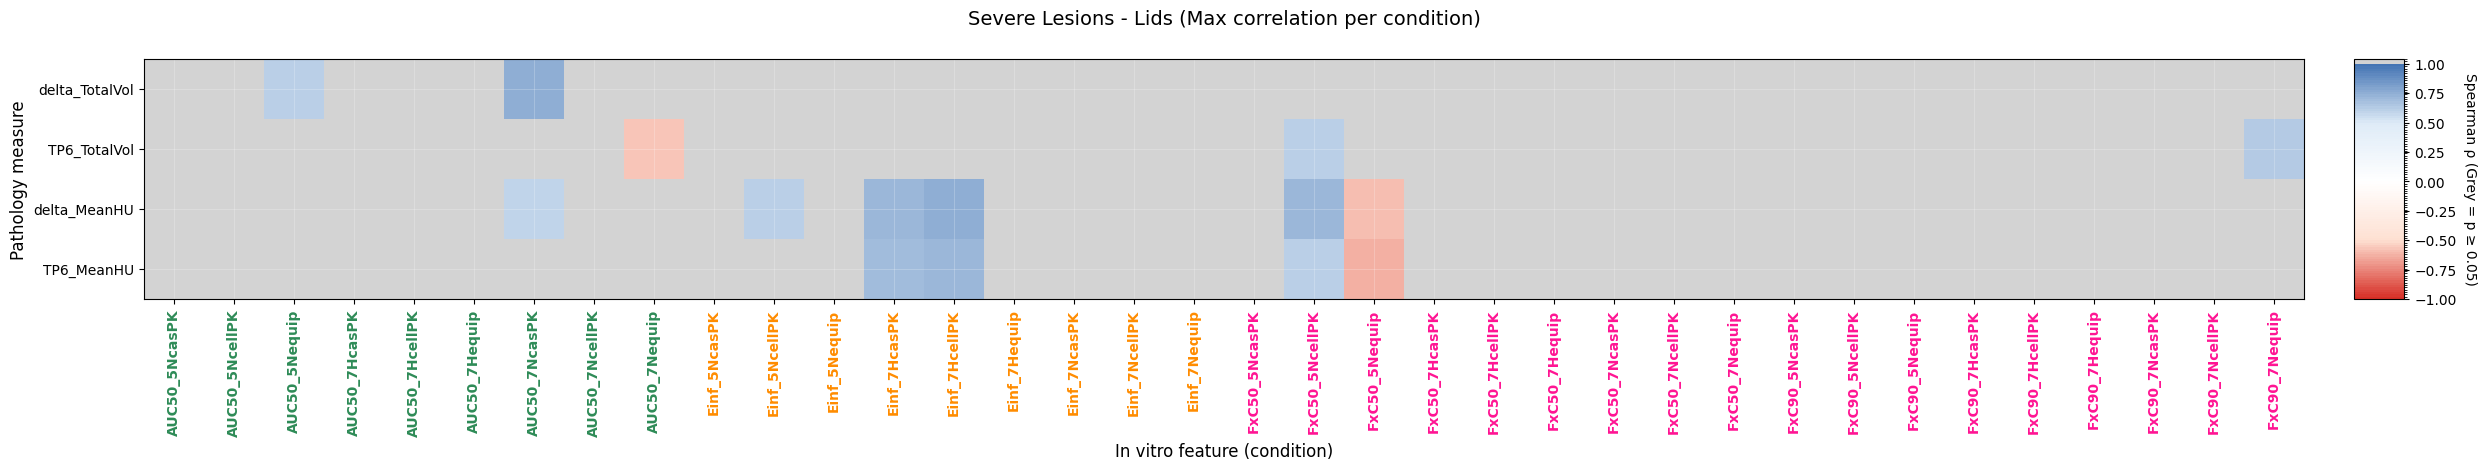


Showing pk category plot:

Showing lids category plot:

Created 3 separate files for severe lesions:
Grey squares now represent correlations with p ≥ 0.05 (non-significant)
Colored squares represent significant correlations (p < 0.05)
Features are now grouped by condition, showing only the timepoint with maximum absolute correlation!

Generated files:
- less_severe_simple.svg (Simple equipotent conditions)
- less_severe_pk.svg (Simple PK conditions)
- less_severe_lids.svg (LIDS conditions)
- severe_simple.svg (Simple equipotent conditions)
- severe_pk.svg (Simple PK conditions)
- severe_lids.svg (LIDS conditions)


In [64]:
# Create category heatmaps for severe lesions
print("\n=== SEVERE LESIONS - CATEGORY BREAKDOWN ===")
severe_figures = plotter.create_category_heatmaps(
    severity='severe',
    plot_type='rho',
    add_grid=True,
    color_xlabels=True,
    improved_colormap=True,
    debug=True,  # Enable debug output to see counts
    pathology_rows=pathology_rows,
    save_dir="figures_v2/3/",
    include_features=include_in_vitro_features,
    group_by_condition=True  # Group features by condition and select max correlation
)

# Display the figures
for category, (fig, ax) in severe_figures.items():
    print(f"\nShowing {category} category plot:")
    plt.show()

print(f"\nCreated {len(severe_figures)} separate files for severe lesions:")
print(f"Grey squares now represent correlations with p ≥ {ALPHA} (non-significant)")
print("Colored squares represent significant correlations (p < 0.05)")
print("Features are now grouped by condition, showing only the timepoint with maximum absolute correlation!")
print("\nGenerated files:")
print("- less_severe_simple.svg (Simple equipotent conditions)")
print("- less_severe_pk.svg (Simple PK conditions)")
print("- less_severe_lids.svg (LIDS conditions)")
print("- severe_simple.svg (Simple equipotent conditions)")
print("- severe_pk.svg (Simple PK conditions)")
print("- severe_lids.svg (LIDS conditions)")